# Persistence

LangGraph has a built-in persistence layer that saves graph state as checkpoints. When you compile a graph with a checkpointer, a snapshot of the graph state is saved at every step of execution, organized into threads. This enables **human-in-the-loop workflows**, **conversational memory**, **time travel debugging**, and **fault-tolerant execution**.

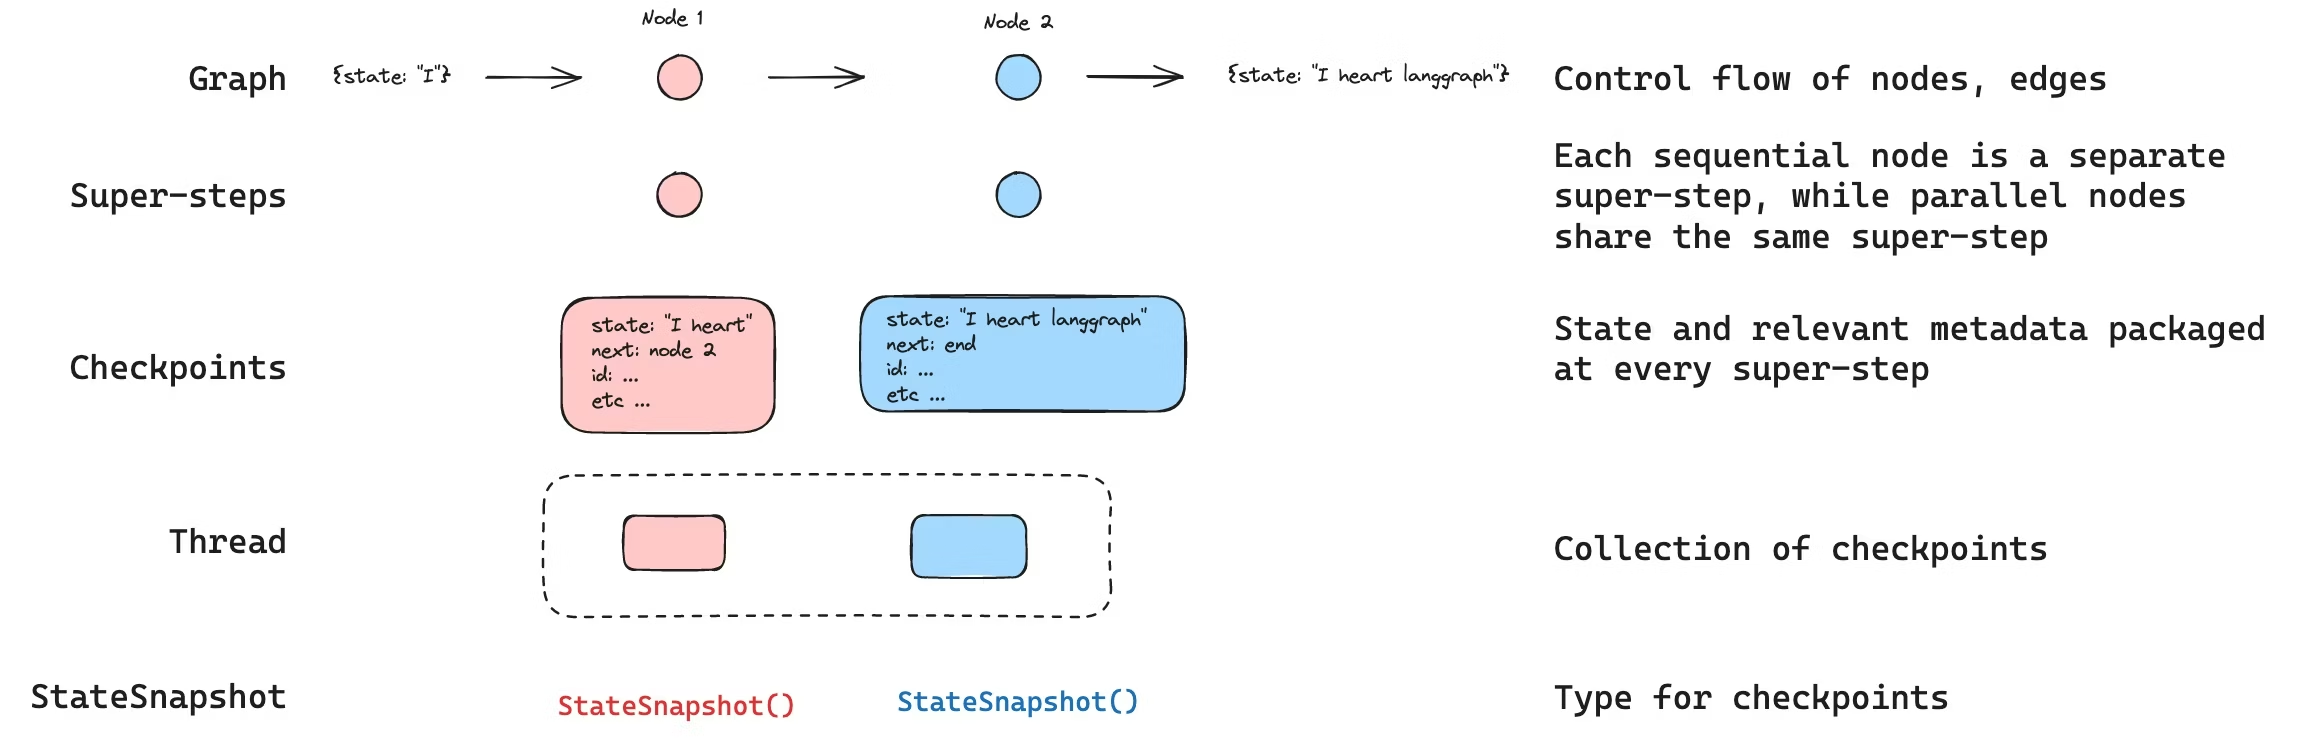

## Why use persistence

Persistence is required for the following features:

* Human-in-the-loop: Checkpointers facilitate human-in-the-loop workflows by allowing humans to inspect, interrupt, and approve graph steps. Checkpointers are needed for these workflows as the person has to be able to view the state of a graph at any point in time, and the graph has to be able to resume execution after the person has made any updates to the state. See Interrupts for examples.
* Memory: Checkpointers allow for “memory” between interactions. In the case of repeated human interactions (like conversations) any follow up messages can be sent to that thread, which will retain its memory of previous ones. See Add memory for information on how to add and manage conversation memory using checkpointers.
* Time travel: Checkpointers allow for “time travel”, allowing users to replay prior graph executions to review and / or debug specific graph steps. In addition, checkpointers make it possible to fork the graph state at arbitrary checkpoints to explore alternative trajectories.
* Fault-tolerance: Checkpointing provides fault-tolerance and error recovery: if one or more nodes fail at a given superstep, you can restart your graph from the last successful step.
* Pending writes: When a graph node fails mid-execution at a given super-step, LangGraph stores pending checkpoint writes from any other nodes that completed successfully at that super-step. When you resume graph execution from that super-step you don’t re-run the successful nodes.

In [3]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ["ANTHROPIC_API_KEY"] = os.getenv("ANTHROPIC_API_KEY")

from langchain.chat_models import init_chat_model

llm = init_chat_model("claude-haiku-4-5", temperature=0, max_tokens=100)

## What is Persistence in LangGraph?

Normally when you run a graph:

```python
graph.invoke(input)
```

After exuction:

```python
state disappears
```
Nothing is saved.

But with **Persistence**, LangGraph **saves the graph state after every step**.

Examples:

```python
Step 1 → state saved
Step 2 → state saved
Step 3 → state saved
```

## Why Persistence Exists

Persistence enables these features:

| Feature | What it does |
| ------- | -------------|
| Human-in-the-loop | Pause graph and wait for human|
| Memory| Keep conversation history|
| Time travel | Replay past conversation|
| Fault tolerance | Retry after crash|

LangGraph stores **snapshots of state at every step** of execution.

## Core Concepts

There are 4 core concepts.

1. Thread
2. Checkpoint
3. Super-step
4. Checkpointer

### Thread

A **thread** represents one session of execution.

```python
Thread 1 → User A conversation
Thread 2 → User B conversation
Thread 3 → Another run
```

Each thread stores **all checkpoints for that run.**

When invoking the graph you must specify:

```python
config = {"configurable": {"thread_id": "1"}}
```

Without `thread_id`, persistence **cannot work**.

**Example:**

thread_id = "chat_1"

```python
chat_1
 ├ checkpoint 1
 ├ checkpoint 2
 └ checkpoint 3
```

### Checkpoint

A **checkpoint = snapshot of graph state**.


```python
{
 "question": "What is LangGraph?",
 "answer": "LangGraph is..."
}
``` 

LangGraph saves this after each step.

```python
Checkpoint 1 → initial input
Checkpoint 2 → after node A
Checkpoint 3 → after node B
Checkpoint 4 → final output
```

This allows:

* Resuming execution

* Debugging graph behavior

* Replaying execution

* Inspecting intermediate state

```python
User Input
   ↓
Checkpoint 1

Node A executes
   ↓
Checkpoint 2

Node B executes
   ↓
Checkpoint 3

Graph finishes
```

Each checkpoint stores:

* current state

* node position

* execution metadata

### Super-Step

A **Super-step** is one **execution cycle in the graph**.

Each super-step may run **one or multiple nodes** depending on graph structure.

After every **super-step**, LangGraph saves a checkpoint.

```python
START → A → B → END
```

Execution process:

```python
Super-step 1 → input
Super-step 2 → node A
Super-step 3 → node B
```

LangGraph saves checkpoints:

```python
Checkpoint 1 → input state
Checkpoint 2 → after node A
Checkpoint 3 → after node B
```

**Visualization**

```python
Input
 ↓
Checkpoint 1

Node A
 ↓
Checkpoint 2

Node B
 ↓
Checkpoint 3
```

So the sequence becomes:

```python
Execution Step
      ↓
Super-step
      ↓
Checkpoint saved
```

In [45]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.runnables import RunnableConfig
from typing import Annotated, TypedDict
from operator import add


class State(TypedDict):
    foo: str
    bar: Annotated[list[str], add]


def node_a(state: State):
    return {"foo": "a", "bar": ["a"]}


def node_b(state: State):
    return {"foo": "b", "bar": ["b"]}


workflow = StateGraph(State)
workflow.add_node(node_a)
workflow.add_node(node_b)
workflow.add_edge(START, "node_a")
workflow.add_edge("node_a", "node_b")
workflow.add_edge("node_b", END)


checkpointer = InMemorySaver()
graph = workflow.compile(checkpointer=checkpointer)

config: RunnableConfig = {"configurable": {"thread_id": "1"}}

graph.invoke({"foo": "", "bar": []}, config)

# get the latest state snapshot
config = {"configurable": {"thread_id": "1"}}
graph.get_state(config)

# get a state snapshot for a specific checkpoint_id
config = {
    "configurable": {
        "thread_id": "1",
        "checkpoint_id": "1f121106-019b-6931-8002-a562549ae717",
    }
}
graph.get_state(config)

config = {"configurable": {"thread_id": "1"}}
list(graph.get_state_history(config))


history = list(graph.get_state_history(config))

# Find the checkpoint before a specific node executed
before_node_b = next(s for s in history if s.next == ("node_b",))

# Find a checkpoint by step number
step_2 = next(s for s in history if s.metadata["step"] == 2)

# Find checkpoints created by update_state
forks = [s for s in history if s.metadata["source"] == "update"]

# Find the checkpoint where an interrupt occurred
interrupted = next(
    (s for s in history if s.tasks and any(t.interrupts for t in s.tasks)), None
)
print(interrupted)

None


### Checkpointer

A **Checkpointer** is the component that **stores checkpoints**.

It defines **where the state is saved**.

LangGraph supports multiple storage backends.

**Built in Checkpointers:**

| Checkpointer | Storage |
| ----------- | ----------- |
| InMemorySaver | RAM |
| SQLiteServer | SQLite Database |
| PostgresSaver | PostgresSQL Database |
| CosmoDBSaver | CosmosDB |

**When to Use Each**

| Environment | Recommended Checkpointer |
| ----------- | ----------- |
| Local testing | InMemorySaver |
| Local apps | SQLiteServer |
| Production apps | PostgresSaver |
| Cloud deployments | CosmosDBServer |

In [8]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver


class State(TypedDict):
    messages: list


def chatbot(state: State):

    messages = state.get("messages", [])

    last_message = messages[-1]

    response = f"Bot reply to: {last_message}"

    messages.append(response)

    return {"messages": messages}


builder = StateGraph(State)

builder.add_node("chatbot", chatbot)

builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)


memory = MemorySaver()

graph = builder.compile(checkpointer=memory)


config = {"configurable": {"thread_id": "chat1"}}


graph.invoke({"messages": ["Hello"]}, config)

graph.invoke({"messages": ["What is LangGraph?"]}, config)

{'messages': ['What is LangGraph?', 'Bot reply to: What is LangGraph?']}

In [21]:
"""
Production-style LangGraph Assistant
Features:
- Persistent conversation (SQLite checkpoints)
- Semantic memory search
- Runtime context (multi-user)
- Memory writing
- Memory retrieval
- State history inspection
"""

import uuid

# import sqlite3
from dataclasses import dataclass
from typing_extensions import TypedDict
from typing import Annotated
from operator import add

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import MessagesState
from langgraph.runtime import Runtime

from langgraph.store.memory import InMemoryStore

# from langgraph.checkpoint.sqlite import SqliteSaver

# from langchain_openai import ChatOpenAI
from langchain_anthropic import ChatAnthropic
from langchain.embeddings import init_embeddings


# ============================================================
# Runtime Context
# ============================================================


@dataclass
class Context:
    user_id: str


# ============================================================
# Graph State
# ============================================================


class State(MessagesState):
    memories: Annotated[list[str], add]


# ============================================================
# LLM Model
# ============================================================

model = ChatAnthropic(model="claude-haiku-4-5", temperature=0)


# ============================================================
# Memory Store (Vector Search)
# ============================================================

store = InMemoryStore()


# ============================================================
# Checkpointer (SQLite)
# ============================================================

# conn = sqlite3.connect("checkpoints.db", check_same_thread=False)
# checkpointer = SqliteSaver(conn)
checkpointer = InMemorySaver()


# ============================================================
# Node 1 : Load Memories
# ============================================================


def load_memories(state: State, runtime: Runtime[Context]):

    user_id = runtime.context.user_id
    namespace = (user_id, "memories")

    last_message = state["messages"][-1].content

    memories = runtime.store.search(namespace, query=last_message, limit=3)

    memory_text = [m.value["memory"] for m in memories]

    return {"memories": memory_text}


# ============================================================
# Node 2 : Call Model
# ============================================================


def call_model(state: State):

    memory_context = "\n".join(state.get("memories", []))

    system_prompt = f"""
You are a helpful assistant with memory.

Relevant memories about the user:
{memory_context}
"""

    response = model.invoke(
        [{"role": "system", "content": system_prompt}, *state["messages"]]
    )

    return {"messages": [response]}


# ============================================================
# Node 3 : Update Memory
# ============================================================


def update_memory(state: State, runtime: Runtime[Context]):

    user_id = runtime.context.user_id
    namespace = (user_id, "memories")

    last_user_message = state["messages"][-2].content

    memory = f"User said: {last_user_message}"

    memory_id = str(uuid.uuid4())

    runtime.store.aput(namespace, memory_id, {"memory": memory})

    return {}


# ============================================================
# Build Graph
# ============================================================

builder = StateGraph(State, context_schema=Context)

builder.add_node("load_memories", load_memories)
builder.add_node("call_model", call_model)
builder.add_node("update_memory", update_memory)

builder.add_edge(START, "load_memories")
builder.add_edge("load_memories", "call_model")
builder.add_edge("call_model", "update_memory")
builder.add_edge("update_memory", END)


# ============================================================
# Compile Graph
# ============================================================

graph = builder.compile(checkpointer=checkpointer, store=store)


# ============================================================
# Runtime Configuration
# ============================================================

config = {"configurable": {"thread_id": "thread-1"}}

context = Context(user_id="user-1")


# ============================================================
# First Conversation
# ============================================================

print("\n---- Conversation 1 ----\n")

for update in graph.stream(
    {"messages": [{"role": "user", "content": "Hi, I love pizza"}]},
    config=config,
    context=context,
    stream_mode="updates",
):
    print(update)


# ============================================================
# Second Conversation (Memory Retrieval)
# ============================================================

print("\n---- Conversation 2 ----\n")

for update in graph.stream(
    {"messages": [{"role": "user", "content": "What food do I like?"}]},
    config=config,
    context=context,
    stream_mode="updates",
):
    print(update)


# ============================================================
# Inspect Current State
# ============================================================

print("\n---- Current State ----\n")

state = graph.get_state(config)

print(state.values)


# ============================================================
# View Checkpoint History
# ============================================================

print("\n---- State History ----\n")

history = list(graph.get_state_history(config))

for snapshot in history:
    print("Step:", snapshot.metadata["step"], "Values:", snapshot.values)


# ============================================================
# Inspect Stored Memories
# ============================================================

print("\n---- Stored Memories ----\n")

namespace = ("user-1", "memories")

memories = store.search(namespace)

for m in memories:
    print(m.dict())


---- Conversation 1 ----

{'load_memories': {'memories': []}}
{'call_model': {'messages': [AIMessage(content="Hi! That's great to know! 🍕 Pizza is such a popular and versatile food – there are so many delicious varieties out there. \n\nDo you have a favorite type of pizza? Are you into classic pepperoni, or do you prefer something with more creative toppings? And are you more of a thin crust or thick crust person?\n\nI'll remember that you love pizza for future conversations!", additional_kwargs={}, response_metadata={'id': 'msg_01GDEJij8utVNrcAsUpxVcpf', 'container': None, 'model': 'claude-haiku-4-5-20251001', 'stop_reason': 'end_turn', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 30, 'output_tokens': 94, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-haiku-4-5-20251001', 

C:\Users\vastadmin\AppData\Local\Temp\ipykernel_4252\4116625504.py:133: RuntimeWarning: coroutine 'BaseStore.aput' was never awaited
  runtime.store.aput(namespace, memory_id, {"memory": memory})


{'call_model': {'messages': [AIMessage(content="Based on what you've told me, you love **pizza**! 🍕\n\nThat's the main thing I know about your food preferences so far. If you'd like to share more about your favorite foods, cuisines, or eating habits, I'd be happy to remember those too!", additional_kwargs={}, response_metadata={'id': 'msg_01EFyFcCspiZMCd5rNdgHewm', 'container': None, 'model': 'claude-haiku-4-5-20251001', 'stop_reason': 'end_turn', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 133, 'output_tokens': 64, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-haiku-4-5-20251001', 'model_provider': 'anthropic'}, id='lc_run--019cf5a3-eda6-73b1-9333-8e9c5790daae-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 133, 'output_tokens': 64, 'total_tokens